In [3]:
import pandas as pd

df = pd.read_csv("../data/british_airways_reviews 2.csv")

df.head()

,Unnamed: 0,title,reviews
0,0,"""unprofessional attitude of the pilots""",BA 246 21JAN 2023 Did not appreciate the unp...
1,1,“Next time it will be Jet2”,Not a great experience. I could not check in ...
2,2,“become the Ryanair of long-haul travel”,I was excited to fly BA as I'd not travelled ...
3,3,“They never help us”,I just want to warn everyone of the worst cu...
4,4,“uncomfortable seat and disgusting food”,Paid for business class travelling Cairo to L...


In [4]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(1300, 3)


In [5]:
df.isnull().sum()

Unnamed: 0    0
title         0
reviews       0
dtype: int64

In [6]:
df["reviews"].sample(5)


1280     Naples to Gatwick. The online check-in would ...
26       Once again a terrible business class experien...
643       Hong Kong to London. Great airline indeed! S...
789       Gatwick to Alicante. 3.5 hours (1 hour sitti...
106       Filthy plane, cabin staff ok, appalling cust...
Name: reviews, dtype: str

In [7]:
df["review_length"] = df["reviews"].str.len()

df["review_length"].describe()

count    1300.000000
mean      827.796923
std       568.608582
min       131.000000
25%       428.750000
50%       682.500000
75%      1047.250000
max      3491.000000
Name: review_length, dtype: float64

In [8]:
import nltk

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [9]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

sample_review = df["reviews"][0]

sia.polarity_scores(sample_review)

{'neg': 0.061, 'neu': 0.869, 'pos': 0.07, 'compound': 0.5013}

In [10]:
df["sentiment_score"] = df["reviews"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

df[["title", "sentiment_score"]].head()

,title,sentiment_score
0,"""unprofessional attitude of the pilots""",0.5013
1,“Next time it will be Jet2”,0.8749
2,“become the Ryanair of long-haul travel”,0.4770
3,“They never help us”,-0.9357
4,“uncomfortable seat and disgusting food”,-0.9686


In [11]:
df["sentiment_score"].describe()

count    1300.000000
mean        0.051315
std         0.788455
min        -0.997400
25%        -0.787075
50%         0.098300
75%         0.908425
max         0.999200
Name: sentiment_score, dtype: float64

In [12]:
def classify_satisfaction(score):
    if score >= 0.05:
        return "Satisfied"
    elif score <= -0.05:
        return "Unsatisfied"
    else:
        return "Neutral"

df["satisfaction_label"] = df["sentiment_score"].apply(classify_satisfaction)

df[["title", "sentiment_score", "satisfaction_label"]].head()

,title,sentiment_score,satisfaction_label
0,"""unprofessional attitude of the pilots""",0.5013,Satisfied
1,“Next time it will be Jet2”,0.8749,Satisfied
2,“become the Ryanair of long-haul travel”,0.4770,Satisfied
3,“They never help us”,-0.9357,Unsatisfied
4,“uncomfortable seat and disgusting food”,-0.9686,Unsatisfied


In [13]:
df["satisfaction_label"].value_counts()

satisfaction_label
Satisfied      655
Unsatisfied    628
Neutral         17
Name: count, dtype: int64

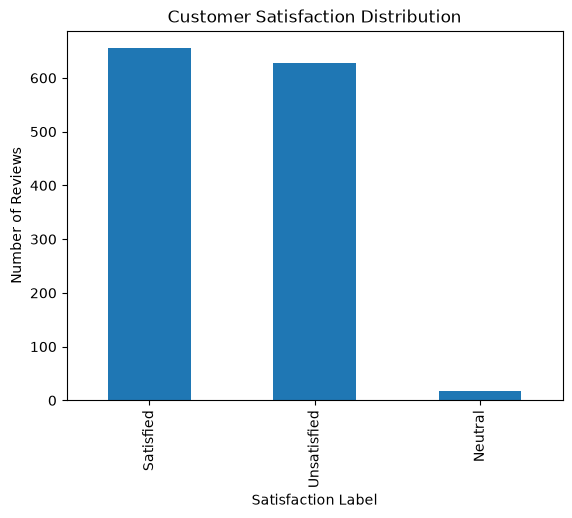

In [14]:
import matplotlib.pyplot as plt

df["satisfaction_label"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Satisfaction Distribution")
plt.xlabel("Satisfaction Label")
plt.ylabel("Number of Reviews")
plt.show()

In [15]:
from collections import Counter
import re

negative_reviews = df[df["satisfaction_label"] == "Unsatisfied"]

all_text = " ".join(negative_reviews["reviews"].astype(str))

words = re.findall(r'\b[a-zA-Z]+\b', all_text.lower())

common_words = Counter(words)

common_words.most_common(30)

[('the', 4625),
 ('to', 3683),
 ('and', 2707),
 ('i', 2216),
 ('a', 2031),
 ('was', 1845),
 ('in', 1350),
 ('flight', 1249),
 ('of', 1242),
 ('for', 1192),
 ('on', 1101),
 ('my', 929),
 ('they', 927),
 ('we', 899),
 ('with', 895),
 ('that', 892),
 ('not', 820),
 ('ba', 820),
 ('it', 751),
 ('is', 718),
 ('had', 685),
 ('no', 681),
 ('at', 649),
 ('were', 614),
 ('have', 579),
 ('this', 562),
 ('but', 529),
 ('me', 511),
 ('from', 497),
 ('as', 467)]

In [16]:
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

common_filtered = Counter(filtered_words)

common_filtered.most_common(30)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('flight', 1249),
 ('service', 439),
 ('london', 404),
 ('british', 308),
 ('airways', 302),
 ('seat', 299),
 ('one', 293),
 ('hours', 291),
 ('class', 285),
 ('time', 272),
 ('staff', 271),
 ('business', 263),
 ('get', 261),
 ('seats', 256),
 ('would', 248),
 ('customer', 239),
 ('food', 238),
 ('told', 226),
 ('heathrow', 225),
 ('airline', 223),
 ('check', 219),
 ('airport', 199),
 ('plane', 195),
 ('even', 190),
 ('back', 189),
 ('could', 187),
 ('crew', 185),
 ('flights', 184),
 ('hour', 180),
 ('cabin', 174)]

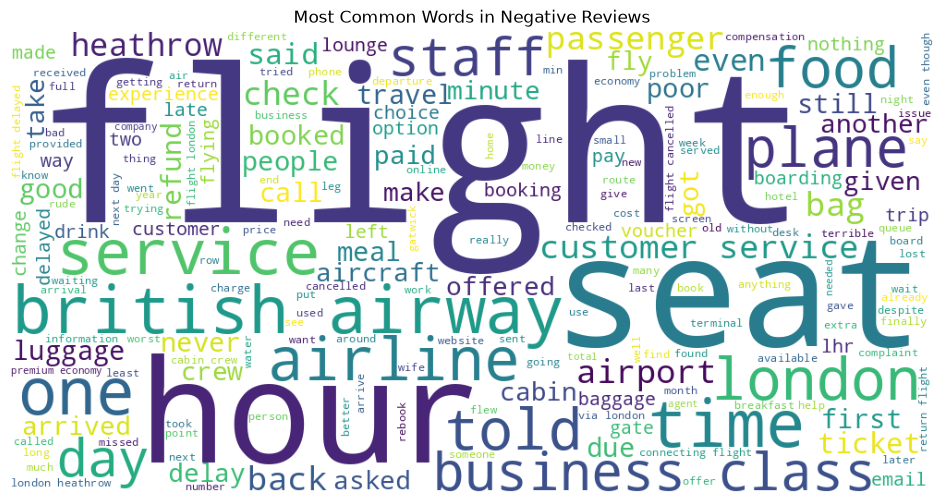

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(" ".join(filtered_words))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words in Negative Reviews")
plt.show()

In [18]:
top_topics = [
    "Flight Delays",
    "Customer Service",
    "Seat Comfort",
    "Food Quality",
    "Airport Experience"
]

for topic in top_topics:
    print(f"Topic: {topic}")

Topic: Flight Delays
Topic: Customer Service
Topic: Seat Comfort
Topic: Food Quality
Topic: Airport Experience


In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import random

# British Airways inspired color palette
ba_colors = [
    "#012169",  # British Airways Navy Blue
    "#003A70",  # Dark Blue
    "#5B92E5",  # Light Blue
    "#7FB3FF",  # Sky Blue
    "#BA0C2F",  # British Airways Red
    "#A50034",  # Dark Red
    "#D71920",  # Bright Red
]

# Function that randomly assigns colors from the BA palette
def ba_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return random.choice(ba_colors)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    collocations=False
).generate(" ".join(filtered_words_v2))

# Apply custom colors
wordcloud = wordcloud.recolor(color_func=ba_color_func)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Most Common Words in Negative Reviews",
    fontsize=18,
    fontweight="bold",
    color="#012169"
)
plt.show()

NameError: name 'filtered_words_v2' is not defined

In [ ]:
custom_stopwords = {
    "one",
    "would",
    "could",
    "even",
    "still",
    "also",
    "really",
    "get",
    "got",
    "back",
    "said",
    "made",
    "make",
    "first",
    "last",
    "next",
    "day",
    "people",
    "time"
}

filtered_words_v2 = [
    word for word in filtered_words
    if word not in custom_stopwords
]

In [ ]:
" ".join(filtered_words_v2)

'want warn everyone worst customer service experience ever looks like british airways customer service phone trained help anyway create problems rather solving week called british airways reservation family explained customer service representative wanted booking pay transfer miles american express representative told reservation miles account asked contact american express transfer booking conversation recorded british airways checked immediately called amex within minutes solicited transfer miles amex clearly stated whether sure transfer reversible fine since checked previously british airways called british airways immediately reservation miami confirmed miles arrived account surprise told space seat miami use miles explained situation led believe flight miles transferred miles went deaf ears called german office absolutely unhelpful called customer service unhelpful manager able open flight miles kept repeating possible though paid flight seats seats available gold status end briti

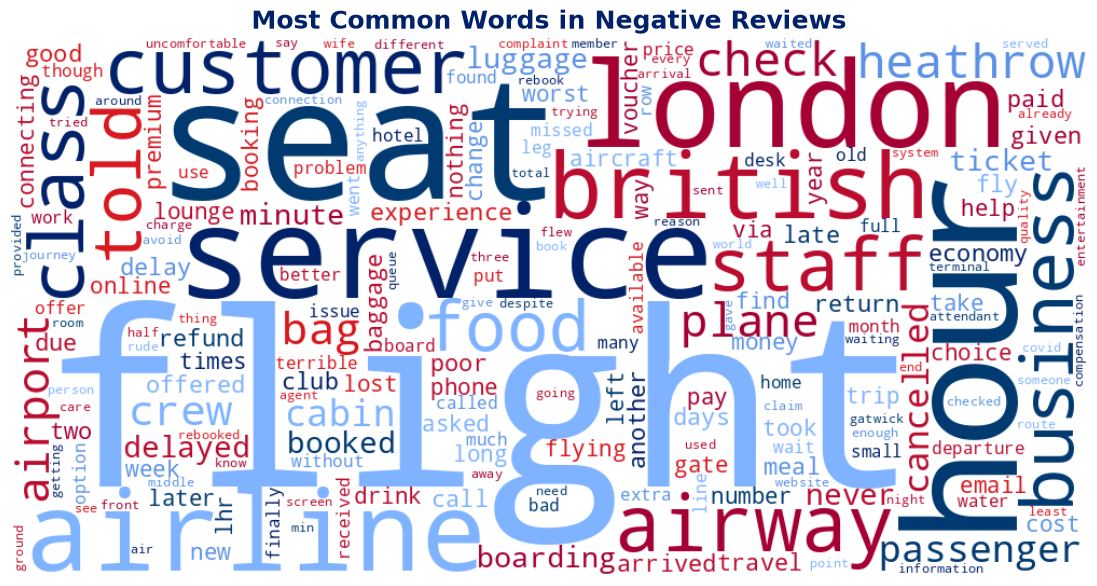

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import random

# British Airways inspired color palette
ba_colors = [
    "#012169",  # British Airways Navy Blue
    "#003A70",  # Dark Blue
    "#5B92E5",  # Light Blue
    "#7FB3FF",  # Sky Blue
    "#BA0C2F",  # British Airways Red
    "#A50034",  # Dark Red
    "#D71920",  # Bright Red
]

# Function that randomly assigns colors from the BA palette
def ba_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return random.choice(ba_colors)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    collocations=False
).generate(" ".join(filtered_words_v2))

# Apply custom colors
wordcloud = wordcloud.recolor(color_func=ba_color_func)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Most Common Words in Negative Reviews",
    fontsize=18,
    fontweight="bold",
    color="#012169"
)
plt.show()

In [ ]:
additional_stopwords = {
    "london",
    "heathrow",
    "british",
    "airways",
    "airway"
}

In [ ]:
recommendations = {
    "Flight Delays": "Improve proactive communication during delays, provide real-time updates, and offer compensation when disruptions occur.",
    
    "Customer Service": "Increase customer service training, reduce response times, and empower staff to resolve issues more efficiently.",
    
    "Seat Comfort": "Review seat quality, cabin maintenance, and passenger comfort standards, especially in premium cabins.",
    
    "Food Quality": "Expand menu options, improve consistency of meal quality, and gather passenger feedback on food offerings.",
    
    "Airport Experience": "Streamline check-in, boarding, and baggage processes to reduce passenger frustration."
}

for category, recommendation in recommendations.items():
    print(f"\n📌 {category}")
    print(f"Recommendation: {recommendation}")


📌 Flight Delays
Recommendation: Improve proactive communication during delays, provide real-time updates, and offer compensation when disruptions occur.

📌 Customer Service
Recommendation: Increase customer service training, reduce response times, and empower staff to resolve issues more efficiently.

📌 Seat Comfort
Recommendation: Review seat quality, cabin maintenance, and passenger comfort standards, especially in premium cabins.

📌 Food Quality
Recommendation: Expand menu options, improve consistency of meal quality, and gather passenger feedback on food offerings.

📌 Airport Experience
Recommendation: Streamline check-in, boarding, and baggage processes to reduce passenger frustration.


In [ ]:
import pandas as pd

recommendations_df = pd.DataFrame(
    recommendations.items(),
    columns=["Complaint Category", "Recommended Action"]
)

recommendations_df

,Complaint Category,Recommended Action
0,Flight Delays,"Improve proactive communication during delays,..."
1,Customer Service,"Increase customer service training, reduce res..."
2,Seat Comfort,"Review seat quality, cabin maintenance, and pa..."
3,Food Quality,"Expand menu options, improve consistency of me..."
4,Airport Experience,"Streamline check-in, boarding, and baggage pro..."


In [ ]:
new_review = """
The flight was delayed for three hours and customer service was unhelpful.
"""

score = sia.polarity_scores(new_review)["compound"]

print("Sentiment Score:", score)

Sentiment Score: -0.2263


In [ ]:
def predict_satisfaction(review_text):
    
    score = sia.polarity_scores(review_text)["compound"]
    
    if score >= 0.05:
        label = "Satisfied"
    elif score <= -0.05:
        label = "Unsatisfied"
    else:
        label = "Neutral"
        
    return score, label

In [ ]:
review = """
The flight was delayed for three hours and customer service was unhelpful.
"""

score, label = predict_satisfaction(review)

print("Sentiment Score:", score)
print("Prediction:", label)

Sentiment Score: -0.2263
Prediction: Unsatisfied


In [ ]:
review = """
The flight was delayed for three hours and customer service was unhelpful.
"""

score, label = predict_satisfaction(review)

print("Review:")
print(review)

print("\nSentiment Score:", round(score, 3))
print("Predicted Satisfaction:", label)

Review:

The flight was delayed for three hours and customer service was unhelpful.


Sentiment Score: -0.226
Predicted Satisfaction: Unsatisfied


In [ ]:
df.to_csv(
    "../data/british_airways_processed.csv",
    index=False
)

NameError: name 'df' is not defined

In [ ]:
processed_df = df[[
    "title",
    "reviews",
    "review_length",
    "sentiment_score",
    "satisfaction_label"
]]

processed_df.head()

,title,reviews,review_length,sentiment_score,satisfaction_label
0,"""unprofessional attitude of the pilots""",BA 246 21JAN 2023 Did not appreciate the unp...,730,0.5013,Satisfied
1,“Next time it will be Jet2”,Not a great experience. I could not check in ...,652,0.8749,Satisfied
2,“become the Ryanair of long-haul travel”,I was excited to fly BA as I'd not travelled ...,1235,0.4770,Satisfied
3,“They never help us”,I just want to warn everyone of the worst cu...,2413,-0.9357,Unsatisfied
4,“uncomfortable seat and disgusting food”,Paid for business class travelling Cairo to L...,461,-0.9686,Unsatisfied


In [ ]:
processed_df.to_csv("../data/british_airways_processed.csv", index=False)

In [ ]:
processed_df.columns

Index(['title', 'reviews', 'review_length', 'sentiment_score',
       'satisfaction_label'],
      dtype='str')

In [ ]:
X = processed_df[["review_length", "sentiment_score"]]

y = processed_df["satisfaction_label"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   review_length  sentiment_score
0            730           0.5013
1            652           0.8749
2           1235           0.4770
3           2413          -0.9357
4            461          -0.9686

Target:
0      Satisfied
1      Satisfied
2      Satisfied
3    Unsatisfied
4    Unsatisfied
Name: satisfaction_label, dtype: str


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 1040
Testing rows: 260


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [ ]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 100.0 %


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

     Neutral       1.00      1.00      1.00         2
   Satisfied       1.00      1.00      1.00       133
 Unsatisfied       1.00      1.00      1.00       125

    accuracy                           1.00       260
   macro avg       1.00      1.00      1.00       260
weighted avg       1.00      1.00      1.00       260



In [ ]:
import joblib

joblib.dump(model, "../src/customer_satisfaction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
def categorize_complaint(text):

    text = text.lower()

    if any(word in text for word in [
        "delay", "delayed", "hours", "late"
    ]):
        return "Flight Delays"

    elif any(word in text for word in [
        "staff", "service", "customer"
    ]):
        return "Customer Service"

    elif any(word in text for word in [
        "seat", "seats", "cabin"
    ]):
        return "Seat Comfort"

    elif any(word in text for word in [
        "food", "meal", "drink"
    ]):
        return "Food Quality"

    elif any(word in text for word in [
        "airport", "check", "boarding"
    ]):
        return "Airport Experience"

    else:
        return "Other"

In [ ]:
negative_reviews["topic"] = negative_reviews["reviews"].apply(
    categorize_complaint
)

negative_reviews[["topic"]].head()

,topic
3,Flight Delays
4,Seat Comfort
5,Flight Delays
6,Flight Delays
8,Flight Delays


In [ ]:
negative_reviews["topic"].value_counts()

topic
Flight Delays         355
Customer Service      165
Seat Comfort           60
Other                  30
Food Quality           10
Airport Experience      8
Name: count, dtype: int64

In [ ]:
negative_reviews["topic"].value_counts()

topic
Flight Delays         355
Customer Service      165
Seat Comfort           60
Other                  30
Food Quality           10
Airport Experience      8
Name: count, dtype: int64

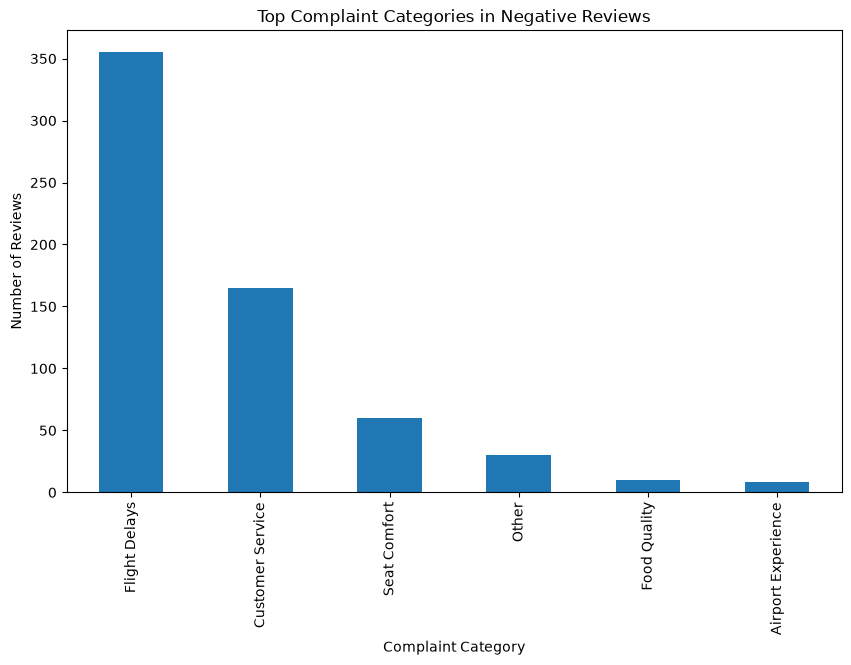

In [ ]:
import matplotlib.pyplot as plt

topic_counts = negative_reviews["topic"].value_counts()

topic_counts.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Top Complaint Categories in Negative Reviews")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Reviews")

plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [21]:
df.head()

,Unnamed: 0,title,reviews,review_length,sentiment_score,satisfaction_label
0,0,"""unprofessional attitude of the pilots""",BA 246 21JAN 2023 Did not appreciate the unp...,730,0.5013,Satisfied
1,1,“Next time it will be Jet2”,Not a great experience. I could not check in ...,652,0.8749,Satisfied
2,2,“become the Ryanair of long-haul travel”,I was excited to fly BA as I'd not travelled ...,1235,0.4770,Satisfied
3,3,“They never help us”,I just want to warn everyone of the worst cu...,2413,-0.9357,Unsatisfied
4,4,“uncomfortable seat and disgusting food”,Paid for business class travelling Cairo to L...,461,-0.9686,Unsatisfied


In [22]:
negative_reviews = df[
    df["satisfaction_label"] == "Unsatisfied"
]

In [23]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=500
)

X_topics = vectorizer.fit_transform(
    negative_reviews["reviews"]
)

In [24]:
lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda.fit(X_topics)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"random_state random_state: int, RandomState instance or None, default=NonePass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0


In [25]:
words = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):

    print(f"\nTopic {topic_idx+1}")

    top_words = [
        words[i]
        for i in topic.argsort()[-10:]
    ]

    print(top_words)


Topic 1
['business', 'crew', 'london', 'class', 'ba', 'heathrow', 'airways', 'flight', 'british', 'service']

Topic 2
['hours', 'service', 'airport', 'told', 'airways', 'british', 'cancelled', 'customer', 'ba', 'flight']

Topic 3
['service', 'passengers', 'good', 'plane', 'time', 'flight', 'staff', 'ba', 'boarding', 'check']

Topic 4
['delay', 'plane', 'luggage', 'time', 'connecting', 'hour', 'hours', 'london', 'delayed', 'flight']

Topic 5
['cabin', 'economy', 'service', 'food', 'business', 'class', 'flight', 'seats', 'ba', 'seat']
